In [228]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from scipy.stats import zscore
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import GridSearchCV
from sklearn import metrics
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
import warnings
warnings.filterwarnings("ignore")

%matplotlib inline

## DOMAIN: Telecom

### 1. Data Understanding & Exploration

**A. Read ‘TelcomCustomer-Churn_1.csv’ as a DataFrame and assign it to a variable.**


In [229]:
T1=pd.read_csv("TelcomCustomer-Churn_1.csv")
T1.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No


In [230]:
T1.shape

(7043, 10)

**B. Read ‘TelcomCustomer-Churn_2.csv’ as a DataFrame and assign it to a variable.**

In [231]:
T2=pd.read_csv("TelcomCustomer-Churn_2.csv")
T2

,customerID,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [232]:
T2.shape

(7043, 12)

**C. Merge both the DataFrames on key ‘customerID’ to form a single DataFrame**

In [233]:
T12=pd.merge(T1,T2,how='outer',on='customerID')

In [234]:
T12.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


**D. Verify if all the columns are incorporated in the merged DataFrame by using simple comparison Operator in Python**

In [235]:
T1.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity'],
      dtype='object')

In [236]:
print("Checking if the values match in the T1 and T12 dataset ")
cols1=['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity']
for i in cols1:
    if T12[T12[i]!=T1[i]].shape[0]==0:
        print("Values match in the column: ",i)
    else:
        print("Values do not match in the column: ",i)


Checking if the values match in the T1 and T12 dataset 
Values match in the column:  customerID
Values match in the column:  gender
Values match in the column:  SeniorCitizen
Values match in the column:  Partner
Values match in the column:  Dependents
Values match in the column:  tenure
Values match in the column:  PhoneService
Values match in the column:  MultipleLines
Values match in the column:  InternetService
Values match in the column:  OnlineSecurity


In [237]:
T2.columns

Index(['customerID', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [238]:
print("Checking if the values match in the T2 and T12 dataset ")
cols2=['customerID', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']
for i in cols2:
    if T12[T12[i]!=T2[i]].shape[0]==0:
        print("Values match in the column: ",i)
    else:
        print("Values do not match in the column: ",i)

Checking if the values match in the T2 and T12 dataset 
Values match in the column:  customerID
Values match in the column:  OnlineBackup
Values match in the column:  DeviceProtection
Values match in the column:  TechSupport
Values match in the column:  StreamingTV
Values match in the column:  StreamingMovies
Values match in the column:  Contract
Values match in the column:  PaperlessBilling
Values match in the column:  PaymentMethod
Values match in the column:  MonthlyCharges
Values match in the column:  TotalCharges
Values match in the column:  Churn


### 2. Data Cleaning & Analysis

**A. Impute missing/unexpected values in the DataFrame.**

In [239]:
T12.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [240]:
#Checking if there are any missing values in the columns
T12.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [241]:
for i in T12.columns:
    print(i)
    print(T12[i].value_counts())
    print("__"*40)

customerID
7590-VHVEG    1
3791-LGQCY    1
6008-NAIXK    1
5956-YHHRX    1
5365-LLFYV    1
             ..
9796-MVYXX    1
2637-FKFSY    1
1552-AAGRX    1
4304-TSPVK    1
3186-AJIEK    1
Name: customerID, Length: 7043, dtype: int64
________________________________________________________________________________
gender
Male      3555
Female    3488
Name: gender, dtype: int64
________________________________________________________________________________
SeniorCitizen
0    5901
1    1142
Name: SeniorCitizen, dtype: int64
________________________________________________________________________________
Partner
No     3641
Yes    3402
Name: Partner, dtype: int64
________________________________________________________________________________
Dependents
No     4933
Yes    2110
Name: Dependents, dtype: int64
________________________________________________________________________________
tenure
1     613
72    362
2     238
3     200
4     176
     ... 
28     57
39     56
44     51
36     5

In [242]:
T12[T12["TotalCharges"]==" "]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [243]:
#Let us find if the data is balanced
print("% of Churned customers",(T12.loc[T12["Churn"]=="Yes",:].shape[0])/7043)
print("% of Not Churned customers",(T12.loc[T12["Churn"]=="No",:].shape[0])/7043)

% of Churned customers 0.2653698707936959
% of Not Churned customers 0.7346301292063041


The % of customers who has not churned or ended the service is very much higher than the number of customers who have left the service. For the datapoints where the TotalCharges is set to " ", the churn value is "No" and the number of such rows is only 11 so instead of imputing the missing values with the mean which is very large, we can remove the 11 rows from the dataset.

In [244]:
T12.drop(T12[T12["TotalCharges"]==" "].index,inplace=True,axis=0)

In [245]:
T12[T12["TotalCharges"]==" "]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn


In [246]:
T12.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 


When taking a look at the "Device Protection" and "Tech support" columns there are datapoints with entry as "No Internet service". 
This could have been a copy paste error since device protection could also mean protection for the phone service in place similarly the Tech support column. So instead of marking as "No internet Service" , we can replace it with "No".

In [247]:
#Checking if the Phone service is "Yes" for the column Device Protection is No internet service 
T12.loc[T12["DeviceProtection"]=="No internet service","PhoneService"].unique()

array(['Yes'], dtype=object)

In [248]:
#Checking if the Phone service is "Yes" for the column TechSupport is No internet service
T12.loc[T12["TechSupport"]=="No internet service","PhoneService"].unique()

array(['Yes'], dtype=object)

In [249]:
#Replacing the "Device Protection" = "No internet service" to "No"
T12["DeviceProtection"].replace("No internet service","No",inplace=True)

In [250]:
T12[T12["DeviceProtection"]=="No internet service"]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn


In [251]:
#Replacing the "TechSupport" = "No internet service" to "No"
T12["TechSupport"].replace("No internet service","No",inplace=True)

In [252]:
T12[T12["TechSupport"]=="No internet service"]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn


In [253]:
#Checking if there are any duplicated columns in the dataset
T12.duplicated().sum()

0

**B. Make sure all the variables with continuous values are of ‘Float’ type.**

In [254]:
#In the combined dataset T12, there are 2 features with continuous values "MonthlyCharges" and "TotalCharges"
T12["MonthlyCharges"]=T12["MonthlyCharges"].astype(float)
T12["TotalCharges"]=T12["TotalCharges"].astype(float)

In [255]:
T12.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 


Converting columns "SeniorCitizen " into object datatype

In [256]:
T12["SeniorCitizen"]=T12["SeniorCitizen"].astype(object)

In [257]:
T12.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   object 
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 


In [258]:
#Deleting the customer ID column
T12.drop("customerID",axis=1,inplace=True)

In [259]:
T12.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 7032 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7032 non-null   object 
 1   SeniorCitizen     7032 non-null   object 
 2   Partner           7032 non-null   object 
 3   Dependents        7032 non-null   object 
 4   tenure            7032 non-null   int64  
 5   PhoneService      7032 non-null   object 
 6   MultipleLines     7032 non-null   object 
 7   InternetService   7032 non-null   object 
 8   OnlineSecurity    7032 non-null   object 
 9   OnlineBackup      7032 non-null   object 
 10  DeviceProtection  7032 non-null   object 
 11  TechSupport       7032 non-null   object 
 12  StreamingTV       7032 non-null   object 
 13  StreamingMovies   7032 non-null   object 
 14  Contract          7032 non-null   object 
 15  PaperlessBilling  7032 non-null   object 
 16  PaymentMethod     7032 non-null   object 


**C. Create a function that will accept a DataFrame as input and return pie-charts for all the appropriate Categorical features. Clearly show percentage distribution in the pie-chart.**

In [260]:
def piechart(dataframe):
    #savings all the categorical columns in the dataset into a new list
    columns=[]
    for i in dataframe.columns:
        if dataframe[i].dtypes=='O':
            columns.append(i)
            
    for j in columns:
        plt.figure(figsize=(6,6))
        title="Pie Chart for the feature :" + j
        plt.title(title)
        plt.pie(dataframe[j].value_counts(),labels=dataframe[j].value_counts().index,autopct="%1.1f%%")
        plt.show()

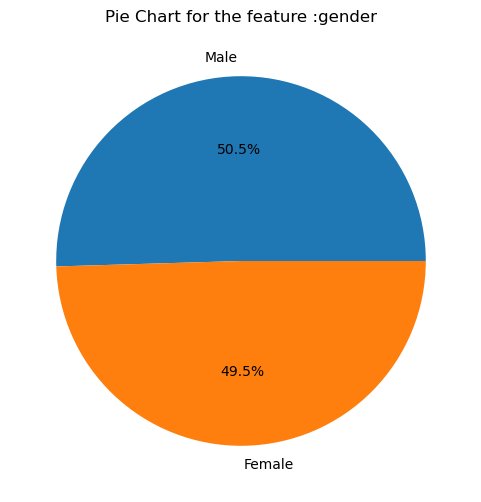

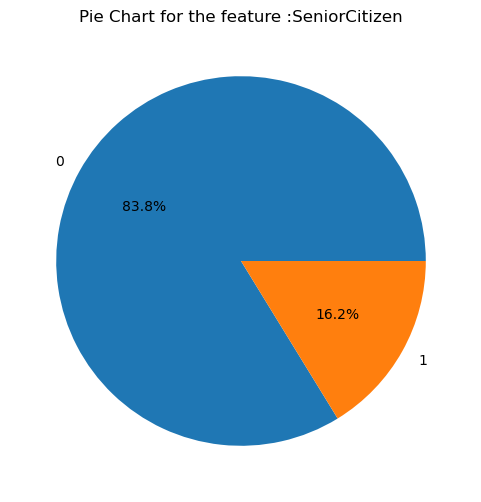

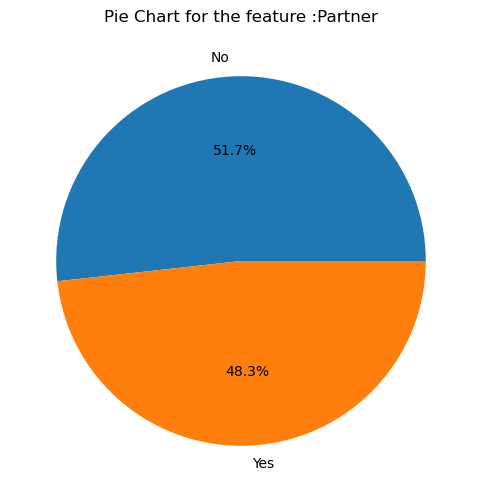

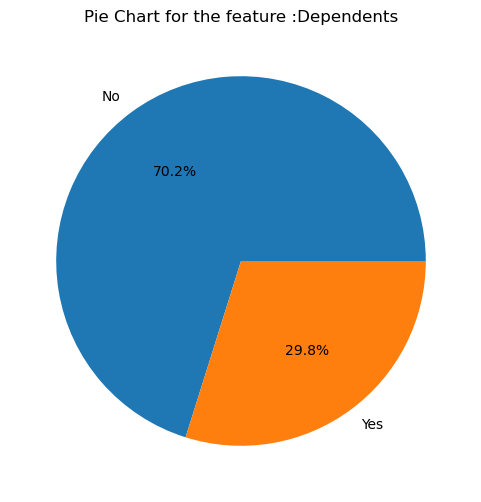

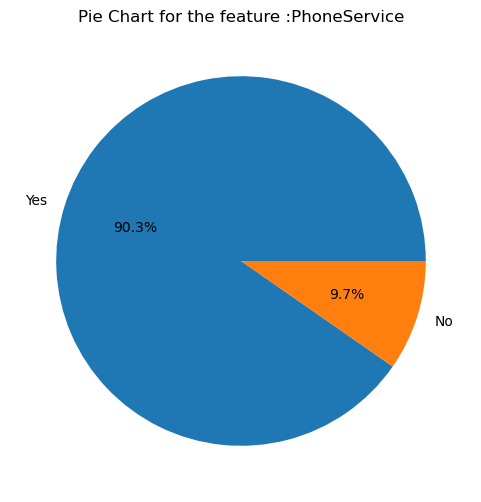

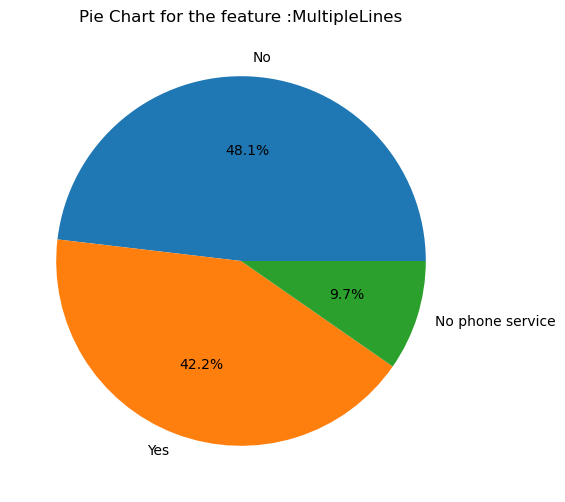

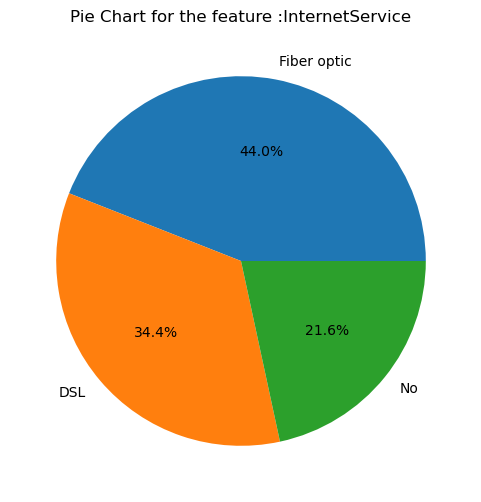

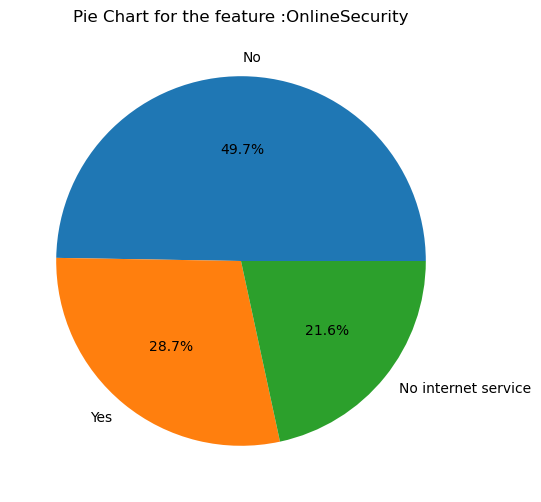

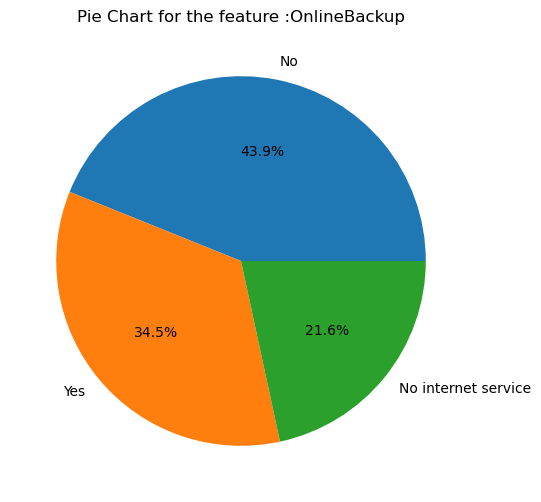

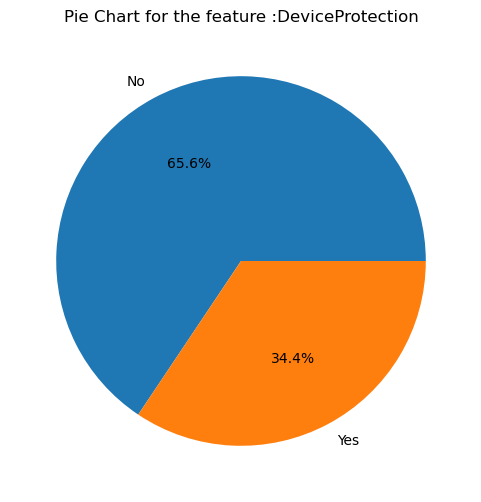

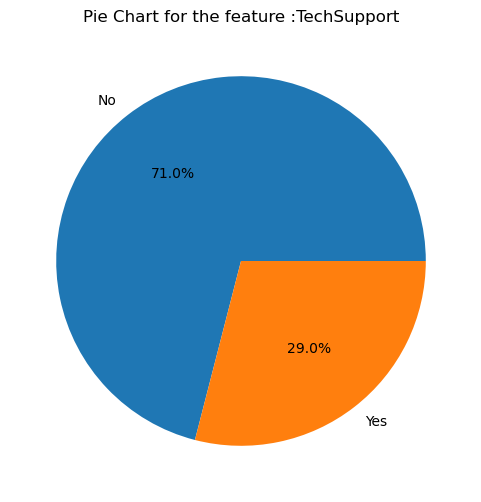

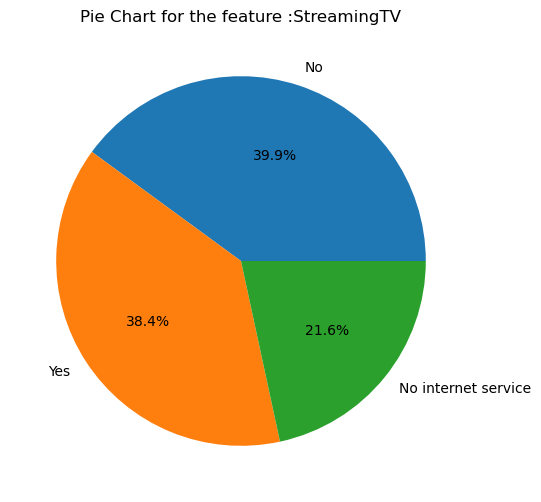

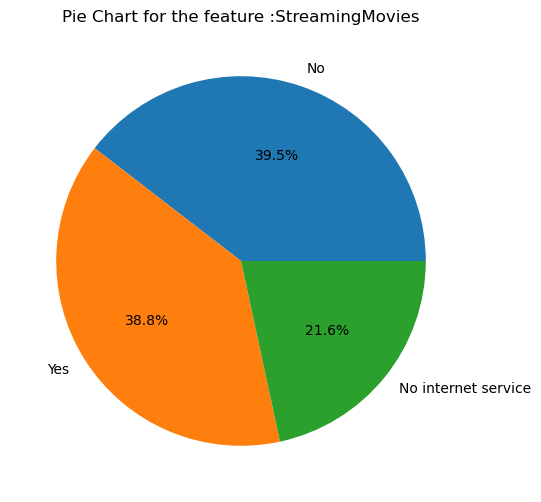

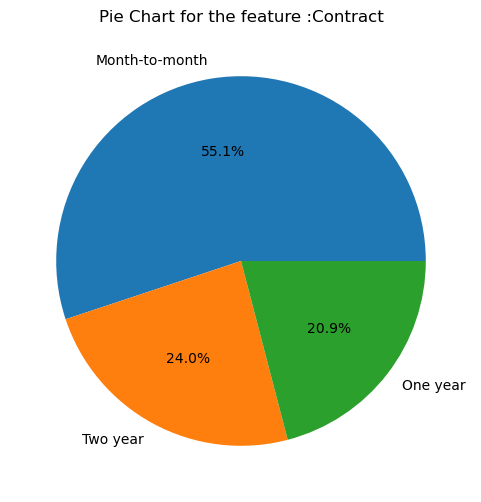

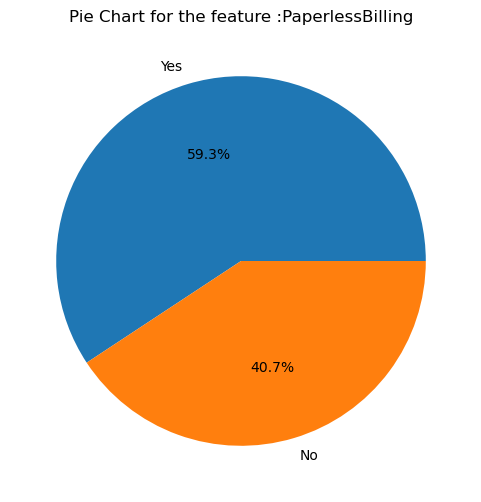

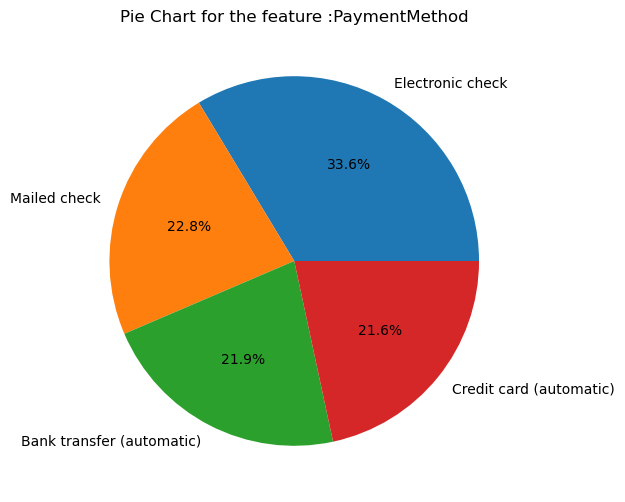

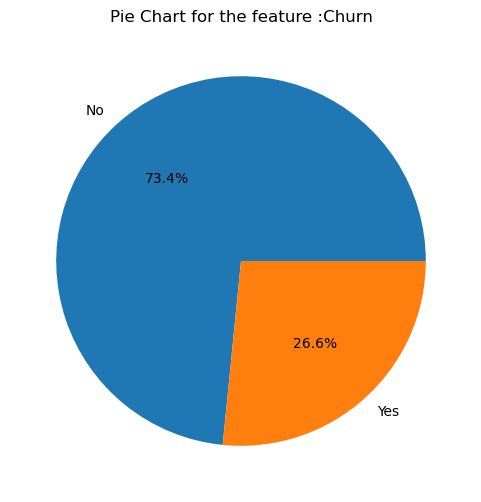

In [261]:
piechart(T12)

**D. Share insights for Q2.c.**

Insights on the pie charts created in Q2.c
 - The dataset is almost distributed equally wrt the gender,50% are female and 50% are male
 - In the entire dataset there are only 16.2% are senior citizens
 - Just a little mpore than half datapoints does not have partners
 - Around 30% have dependants and 70% are not having any dependants
 - 90% of the dataset have phone service
 - Of the 90% of datapoints who have phone service only 42% have opted for multiple lines, 48% does not have multiple lines
 - 78.4% have opted for internet service of which 34.4% uses DSL and 44% uses fiber optic
 - Of the 78.4% who has opted for internet service only 28.7% have opted for online security
 - 34.5% of the internet users have opted for Online Backup and close to 44% have not opted for online backup
 - Only 34.4% have opted for device protection
 - Only 30% of the users have opted for TechSupport
 - 38.4% of users have opted for Streaming TV service
 - Streaming Movies have a similar interest as that for the Streaming TV
 - Slightly more than half the customers have opted for Month-Month contract
 - There is almost an equal customer interest for 2 year and 1 year contract
 - 60% of the customers have opted for Paperless billing
 - Customers who has opted for Payment method as Bank Tranfer, Mailed check and credit card(automatic) are almost the same(~22%)
 - 33% of customers have opted for Electronic check
 - Dataset is imblanced with 74% of customer who still has the service and 26 has opted out of the service in the last month

**E. Encode all the appropriate Categorical features with the best suitable approach.**

In [262]:
#Categorical columns in the dataset
cat_columns=[]
for i in T12.columns:
        if T12[i].dtypes=='O':
            cat_columns.append(i)
cat_columns

['gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'Churn']

In [263]:
for j in cat_columns:
    print("Column : ",j)
    print(T12[j].unique())
    print("__"*25)
    

Column :  gender
['Female' 'Male']
__________________________________________________
Column :  SeniorCitizen
[0 1]
__________________________________________________
Column :  Partner
['Yes' 'No']
__________________________________________________
Column :  Dependents
['No' 'Yes']
__________________________________________________
Column :  PhoneService
['No' 'Yes']
__________________________________________________
Column :  MultipleLines
['No phone service' 'No' 'Yes']
__________________________________________________
Column :  InternetService
['DSL' 'Fiber optic' 'No']
__________________________________________________
Column :  OnlineSecurity
['No' 'Yes' 'No internet service']
__________________________________________________
Column :  OnlineBackup
['Yes' 'No' 'No internet service']
__________________________________________________
Column :  DeviceProtection
['No' 'Yes']
__________________________________________________
Column :  TechSupport
['No' 'Yes']
______________________

All the categorical variables are nominal variables which means there is no particular order for the values in the column.
So we can either use One hot encoding or Dummy encoding technique for categorical enoding. <br>
Let us consider dummy encoding

In [264]:
for i in cat_columns:
    T12=pd.get_dummies(T12,columns=[i],drop_first=True)

**F. Split the data into 80% train and 20% test.**

In [265]:
X=T12.drop("Churn_Yes",axis=1)
y=T12["Churn_Yes"]

In [266]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,stratify=y,random_state=1)

**G. Normalize/Standardize the data with the best suitable approach.**

In [267]:
X_train

,tenure,MonthlyCharges,TotalCharges,gender_Male,SeniorCitizen_1,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
1038,56,80.90,4557.50,1,0,1,0,1,0,0,...,0,0,0,1,1,0,1,0,1,0
1016,71,80.10,5585.40,1,0,1,0,1,0,1,...,0,0,0,1,0,1,1,0,0,1
3255,66,110.60,7210.85,0,1,1,1,1,0,1,...,0,1,0,1,1,0,1,1,0,0
6381,1,19.55,19.55,1,0,0,1,1,0,0,...,1,0,1,0,0,0,0,0,0,1
6296,31,50.40,1580.10,0,1,1,0,0,1,0,...,0,0,0,1,1,0,1,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100,1,20.20,20.20,1,0,0,0,1,0,0,...,1,0,1,0,0,0,0,0,0,1
5349,69,114.35,7665.80,1,0,1,1,1,0,1,...,0,1,0,1,0,1,1,0,0,0
5889,59,50.25,2997.45,1,1,1,0,0,1,0,...,0,1,0,1,0,0,1,0,1,0
1999,23,74.95,1710.45,1,0,0,0,1,0,1,...,0,0,0,0,0,0,1,0,1,0


In [268]:
X_test

,tenure,MonthlyCharges,TotalCharges,gender_Male,SeniorCitizen_1,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
6904,64,43.85,2751.00,0,1,0,0,0,1,0,...,0,1,0,0,0,0,1,0,1,0
2209,8,19.55,161.15,1,0,1,0,1,0,0,...,1,0,1,0,0,0,1,0,0,0
2910,35,25.40,949.80,0,0,1,1,1,0,1,...,1,0,1,0,0,1,1,1,0,0
3854,50,109.65,5405.80,0,0,1,0,1,0,1,...,0,1,0,1,0,0,1,0,0,0
6385,4,101.70,364.55,1,0,0,1,1,0,1,...,0,1,0,1,0,0,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999,2,70.30,132.40,1,0,0,0,1,0,0,...,0,1,0,1,0,0,0,0,1,0
60,47,100.50,4707.10,0,0,1,0,1,0,1,...,0,1,0,1,0,0,1,0,1,0
425,55,51.65,2838.55,0,1,1,0,1,0,1,...,0,0,0,0,0,0,0,0,0,0
1120,20,70.55,1493.55,1,0,0,0,1,0,0,...,0,0,0,0,0,0,0,1,0,0


In the independant variables, there are 3 numeric columns that is tenure, Monthly charges and Total charges.<br>
Hence the scaling has to be performed for these columns.

In [269]:
std_scaler = StandardScaler()

num_cols=["tenure","MonthlyCharges","TotalCharges"]
for i in num_cols:
    X_train[i] = std_scaler.fit_transform(X_train[[i]])
    X_test[i]=std_scaler.fit_transform(X_test[[i]])

### 3. Model building and performance improvement 

**A. Train a model using Decision tree and check the performance of the model on train and test data**

In [270]:
DTree=DecisionTreeClassifier(random_state=1)
DTree.fit(X_train,y_train)

DecisionTreeClassifier(random_state=1)

In [271]:
#Function to find the performance parameters for the model.

def Performance_parameters(model,x_test,x_train,y_test,y_train):
    y_train_pred=model.predict(x_train)
    y_test_pred=model.predict(x_test)
    print("Accuracy of the model for the training data is: ",model.score(x_train,y_train))
    print("Accuracy of the model for the testing data is: ", model.score(x_test,y_test))
    #print("F1 score for the traning data: ",model.f1_score(y_train,y_train_pred))
    #print("F1 score for the testing data: ",model.f1_score(y_test,y_test_pred))
    #print("Precision score for the training data: ",model.precision_score(y_train,y_train_pred))
    #print("Precision score for the testing data: ",model.precision_score(y_test,y_test_pred))
    #print("Recall score for the training data: ",model.recall_score(y_train,y_train_pred))
    #print("Recall score for the testing data: ",model.recall_score(y_test,y_test_pred))
    
    #y_pred=model.predict(x_test)
    cm_test=metrics.confusion_matrix(y_test, y_test_pred, labels=[1, 0])
    df_cm_test = pd.DataFrame(cm_test, index = [i for i in ["1","0"]],columns = [i for i in ["Predict 1","Predict 0"]])
    print("__"*30)
    print("      Confusion Matrix on Testing data               ")
    print("__"*30)    
    plt.figure(figsize = (7,5))
    sns.heatmap(df_cm_test, annot=True,fmt='g')
    plt.show();
    print("__"*30)
    print("        Classification Report on testing data")
    print("__"*30)
    print(metrics.classification_report(y_test, y_test_pred, labels=[1, 0]))
    
    
    cm_train=metrics.confusion_matrix(y_train, y_train_pred, labels=[1, 0])
    df_cm_train = pd.DataFrame(cm_train, index = [i for i in ["1","0"]],columns = [i for i in ["Predict 1","Predict 0"]])
    print("__"*30)
    print("      Confusion Matrix on Training data               ")
    print("__"*30)    
    plt.figure(figsize = (7,5))
    sns.heatmap(df_cm_train, annot=True,fmt='g')
    plt.show();
    print("__"*30)
    print("        Classification Report on Training data")
    print("__"*30)
    print(metrics.classification_report(y_train, y_train_pred, labels=[1, 0]))

Accuracy of the model for the training data is:  0.9971555555555556
Accuracy of the model for the testing data is:  0.7420042643923241
____________________________________________________________
      Confusion Matrix on Testing data               
____________________________________________________________


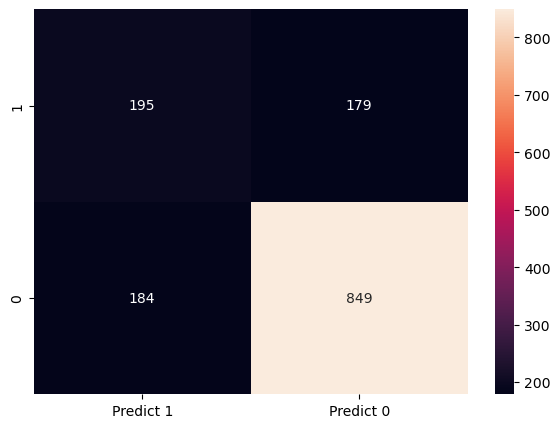

____________________________________________________________
        Classification Report on testing data
____________________________________________________________
              precision    recall  f1-score   support

           1       0.51      0.52      0.52       374
           0       0.83      0.82      0.82      1033

    accuracy                           0.74      1407
   macro avg       0.67      0.67      0.67      1407
weighted avg       0.74      0.74      0.74      1407

____________________________________________________________
      Confusion Matrix on Training data               
____________________________________________________________


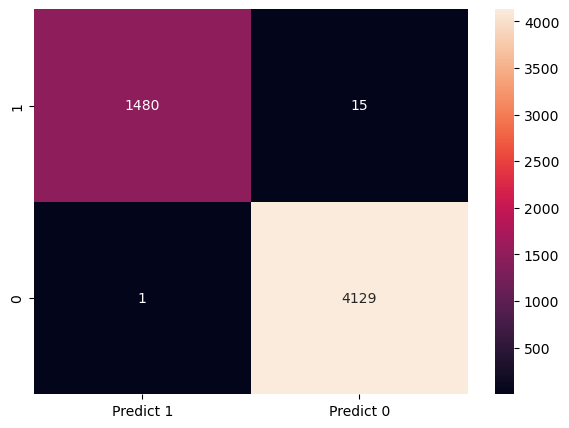

____________________________________________________________
        Classification Report on Training data
____________________________________________________________
              precision    recall  f1-score   support

           1       1.00      0.99      0.99      1495
           0       1.00      1.00      1.00      4130

    accuracy                           1.00      5625
   macro avg       1.00      0.99      1.00      5625
weighted avg       1.00      1.00      1.00      5625



In [272]:
Performance_parameters(DTree,X_test,X_train,y_test,y_train)

In [273]:
Importance=DTree.feature_importances_
Feature_names=DTree.feature_names_in_

print("Feature importance given is as below")
Feature_importance=pd.DataFrame(data=[Feature_names,Importance],index=["Feature","Importance"])
print(Feature_importance.T)

Feature importance given is as below
                                  Feature Importance
0                                  tenure   0.202015
1                          MonthlyCharges   0.195233
2                            TotalCharges   0.209119
3                             gender_Male   0.025685
4                         SeniorCitizen_1   0.026288
5                             Partner_Yes   0.018904
6                          Dependents_Yes   0.017108
7                        PhoneService_Yes   0.002306
8          MultipleLines_No phone service   0.000612
9                       MultipleLines_Yes   0.019328
10            InternetService_Fiber optic   0.110483
11                     InternetService_No        0.0
12     OnlineSecurity_No internet service        0.0
13                     OnlineSecurity_Yes   0.014223
14       OnlineBackup_No internet service        0.0
15                       OnlineBackup_Yes    0.01494
16                   DeviceProtection_Yes   0.010998
17       

**B. Use grid search and improve the performance of the Decision tree model , check the performance of the model on train and test data , provide the differences observed in performance in Q3.a and Q3.**

The hyper parameters for decision tree are as below:
 - criterion: splitting criterion
 - max_depth: maximum depth
 - min_samples_leaf: minimum samples per leaf
 - max_features: number of features considered for splitting

In [45]:
#Initiatilizing the hyper parameters with the values to do the grid search
criterion=["gini","entropy","log_loss"]
max_depth=list(range(3,20,2))
min_samples_leaf=list(range(3,10,2))
max_features=['sqrt', 'log2']
hyperparameters = dict(criterion=criterion,max_depth=max_depth,min_samples_leaf=min_samples_leaf,max_features=max_features)

#Initializing the model as decision tree
DTree_tune=DecisionTreeClassifier()

#Using gridsearch
clf=GridSearchCV(DTree_tune,hyperparameters,cv=5)

#fitting the training data in grid search
best_model=clf.fit(X_train,y_train)

print("The value of best Hyperparameters")
print('Best criterion:', best_model.best_estimator_.get_params()['criterion'])
print("Best value for max_depth: ",best_model.best_estimator_.get_params()["max_depth"])
print("Best value for the min_samples_leaf: ",best_model.best_estimator_.get_params()["min_samples_leaf"])
print("Best value for the max_features: ",best_model.best_estimator_.get_params()["max_features"])

The value of best Hyperparameters
Best criterion: log_loss
Best value for max_depth:  7
Best value for the min_samples_leaf:  7
Best value for the max_features:  sqrt


In [274]:
DTree_Tuned=DecisionTreeClassifier(criterion="log_loss",max_depth=7,min_samples_leaf=7,max_features="sqrt",random_state=1)
DTree_Tuned.fit(X_train,y_train)

DecisionTreeClassifier(criterion='log_loss', max_depth=7, max_features='sqrt',
                       min_samples_leaf=7, random_state=1)

Accuracy of the model for the training data is:  0.7994666666666667
Accuracy of the model for the testing data is:  0.7718550106609808
____________________________________________________________
      Confusion Matrix on Testing data               
____________________________________________________________


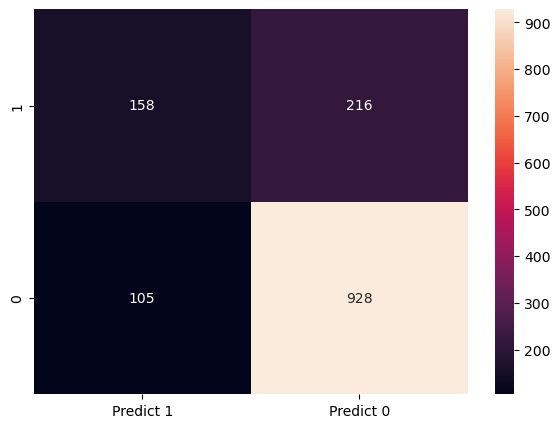

____________________________________________________________
        Classification Report on testing data
____________________________________________________________
              precision    recall  f1-score   support

           1       0.60      0.42      0.50       374
           0       0.81      0.90      0.85      1033

    accuracy                           0.77      1407
   macro avg       0.71      0.66      0.67      1407
weighted avg       0.76      0.77      0.76      1407

____________________________________________________________
      Confusion Matrix on Training data               
____________________________________________________________


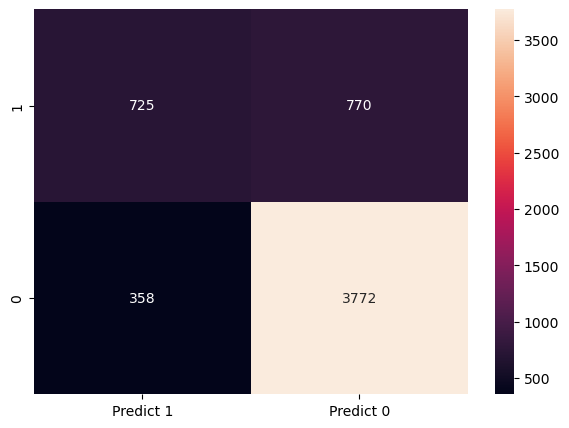

____________________________________________________________
        Classification Report on Training data
____________________________________________________________
              precision    recall  f1-score   support

           1       0.67      0.48      0.56      1495
           0       0.83      0.91      0.87      4130

    accuracy                           0.80      5625
   macro avg       0.75      0.70      0.72      5625
weighted avg       0.79      0.80      0.79      5625



In [275]:
Performance_parameters(DTree_Tuned,X_test,X_train,y_test,y_train)

In [276]:
Importance=DTree_Tuned.feature_importances_
Feature_names=DTree_Tuned.feature_names_in_

print("Feature importance for Decision Tree Tuned model is as given below")
Feature_importance=pd.DataFrame(data=[Feature_names,Importance],index=["Feature","Importance"])
print(Feature_importance.T)

Feature importance for Decision Tree Tuned model is as given below
                                  Feature Importance
0                                  tenure   0.339939
1                          MonthlyCharges   0.057227
2                            TotalCharges   0.067435
3                             gender_Male   0.006677
4                         SeniorCitizen_1   0.002984
5                             Partner_Yes   0.002089
6                          Dependents_Yes   0.007743
7                        PhoneService_Yes        0.0
8          MultipleLines_No phone service        0.0
9                       MultipleLines_Yes   0.003509
10            InternetService_Fiber optic    0.02618
11                     InternetService_No   0.200788
12     OnlineSecurity_No internet service        0.0
13                     OnlineSecurity_Yes   0.062417
14       OnlineBackup_No internet service        0.0
15                       OnlineBackup_Yes   0.009907
16                   DeviceProte

The objective of the model is to find out the customers who are most probably going to churn or terminate the service and with this data in hand, the company can focus on customer retention strategies on the customers who are more likely to churn. So it is very important to correctly identify the customers who are more likely to end the service i.e, more focus should be on identifying the positives that is TP should be high. so the performance metrics which is of higher importance will be recall.
 - Recall: how many positives were correctly identified from the actual positives.


**Decision Tree base model:**

- The training data is clearly overfitting since the model accuracy is close to 1 for tranining data and 74% for testing data.
- Recall for the testing data is only 52% which means the model is capable of identifying only 50% of the actual positives. 
- Recall for the training data is very high this is due to the overfitting.
- Precision and F1-score for the testing data is also low.

**Decision tree with the tuned hyper parameters:**
 - Accuracy for the testing data has improved for the model with the tuned hyper parameters from 74% to 77%
 - Accuracy for the training data is 80% and is close to the accuracy with the testing data so we can say that the model has overcome the overfitting with the tuned hyper parameters
 - Recall has reduced to 42% from 52% when comparing with the recall for the base model
 - There is an improvement in the precision for the tuned model
 - F1-score is almost the same as that of the base model

**C. Train a model using Random forest and check the performance of the model on train and test data**

In [277]:
R_Forest=RandomForestClassifier(random_state=1)
R_Forest.fit(X_train,y_train)

RandomForestClassifier(random_state=1)

Accuracy of the model for the training data is:  0.9971555555555556
Accuracy of the model for the testing data is:  0.7853589196872779
____________________________________________________________
      Confusion Matrix on Testing data               
____________________________________________________________


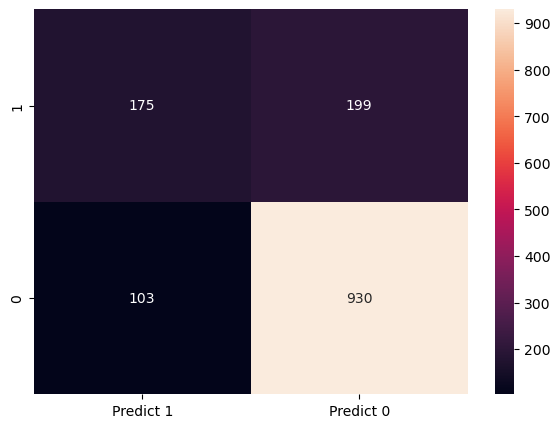

____________________________________________________________
        Classification Report on testing data
____________________________________________________________
              precision    recall  f1-score   support

           1       0.63      0.47      0.54       374
           0       0.82      0.90      0.86      1033

    accuracy                           0.79      1407
   macro avg       0.73      0.68      0.70      1407
weighted avg       0.77      0.79      0.77      1407

____________________________________________________________
      Confusion Matrix on Training data               
____________________________________________________________


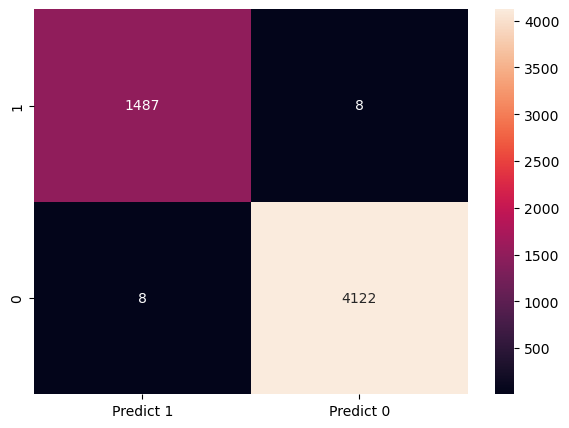

____________________________________________________________
        Classification Report on Training data
____________________________________________________________
              precision    recall  f1-score   support

           1       0.99      0.99      0.99      1495
           0       1.00      1.00      1.00      4130

    accuracy                           1.00      5625
   macro avg       1.00      1.00      1.00      5625
weighted avg       1.00      1.00      1.00      5625



In [278]:
Performance_parameters(R_Forest,X_test,X_train,y_test,y_train)

In [279]:
Importance=R_Forest.feature_importances_
Feature_names=R_Forest.feature_names_in_

print("Feature importance for Decision Tree Tuned model is as given below")
Feature_importance=pd.DataFrame(data=[Feature_names,Importance],index=["Feature","Importance"])
print(Feature_importance.T)

Feature importance for Decision Tree Tuned model is as given below
                                  Feature Importance
0                                  tenure   0.169803
1                          MonthlyCharges   0.168437
2                            TotalCharges   0.196317
3                             gender_Male   0.028814
4                         SeniorCitizen_1   0.020404
5                             Partner_Yes    0.02296
6                          Dependents_Yes   0.019061
7                        PhoneService_Yes   0.004239
8          MultipleLines_No phone service   0.003734
9                       MultipleLines_Yes   0.019267
10            InternetService_Fiber optic   0.040395
11                     InternetService_No   0.007115
12     OnlineSecurity_No internet service   0.005264
13                     OnlineSecurity_Yes   0.023496
14       OnlineBackup_No internet service   0.008211
15                       OnlineBackup_Yes    0.02214
16                   DeviceProte

**D. Use grid search and improve the performance of the Random tree model , check the performance of the model on train and test data , provide the differences observed in performance in Q3.c and Q3.d**

The hyperparameters for the Random Forest model are as below:
 - n_estimators
 - criterion
 - max_depth
 - min_samples_leaf
 - max_features

In [66]:
#Initiatilizing the hyper parameters with the values to do the grid search
n_estimators=[100,150,200]
criterion=["gini","entropy","log_loss"]
max_depth=list(range(3,15,2))
#min_samples_leaf=list(range(3,10,2))
max_features=['sqrt', 'log2']
#hyperparameters = dict(n_estimators=n_estimators,criterion=criterion,max_depth=max_depth,min_samples_leaf=min_samples_leaf,max_features=max_features)
hyperparameters = dict(n_estimators=n_estimators,criterion=criterion,max_depth=max_depth,max_features=max_features)

#Initializing the model as Random Forest
RForest_tune=RandomForestClassifier()

#Using gridsearch
clf=GridSearchCV(RForest_tune,hyperparameters,cv=5)

#fitting the training data in grid search
best_model=clf.fit(X_train,y_train)

print("The value of best Hyperparameters")
print('Best n_estimators:', best_model.best_estimator_.get_params()['n_estimators'])
print('Best criterion:', best_model.best_estimator_.get_params()['criterion'])
print("Best value for max_depth: ",best_model.best_estimator_.get_params()["max_depth"])
#print("Best value for the min_samples_leaf: ",best_model.best_estimator_.get_params()["min_samples_leaf"])
print("Best value for the max_features: ",best_model.best_estimator_.get_params()["max_features"])

The value of best Hyperparameters
Best n_estimators: 200
Best criterion: gini
Best value for max_depth:  9
Best value for the max_features:  log2


In [280]:
#Model creation using the hyper parameters according to grid search
R_Forest_Tuned=RandomForestClassifier(n_estimators=200,criterion="gini",max_depth=9,max_features="log2",random_state=1)
R_Forest_Tuned.fit(X_train,y_train)

RandomForestClassifier(max_depth=9, max_features='log2', n_estimators=200,
                       random_state=1)

Accuracy of the model for the training data is:  0.8419555555555556
Accuracy of the model for the testing data is:  0.7931769722814499
____________________________________________________________
      Confusion Matrix on Testing data               
____________________________________________________________


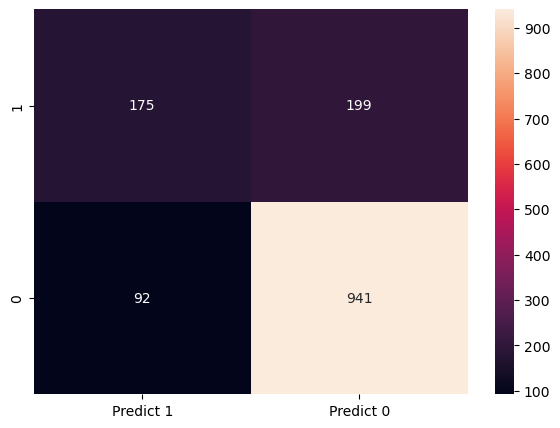

____________________________________________________________
        Classification Report on testing data
____________________________________________________________
              precision    recall  f1-score   support

           1       0.66      0.47      0.55       374
           0       0.83      0.91      0.87      1033

    accuracy                           0.79      1407
   macro avg       0.74      0.69      0.71      1407
weighted avg       0.78      0.79      0.78      1407

____________________________________________________________
      Confusion Matrix on Training data               
____________________________________________________________


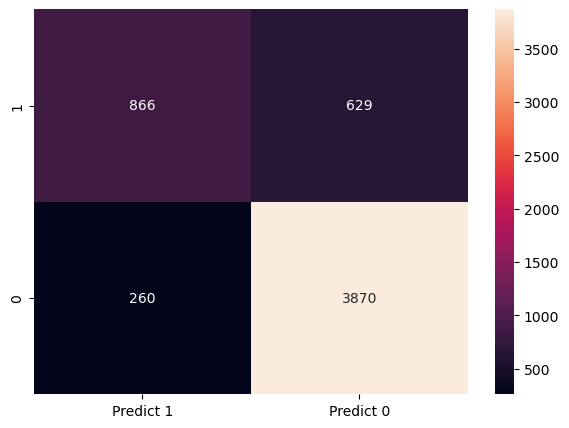

____________________________________________________________
        Classification Report on Training data
____________________________________________________________
              precision    recall  f1-score   support

           1       0.77      0.58      0.66      1495
           0       0.86      0.94      0.90      4130

    accuracy                           0.84      5625
   macro avg       0.81      0.76      0.78      5625
weighted avg       0.84      0.84      0.83      5625



In [281]:
Performance_parameters(R_Forest_Tuned,X_test,X_train,y_test,y_train)

In [282]:
Importance=R_Forest_Tuned.feature_importances_
Feature_names=R_Forest_Tuned.feature_names_in_

print("Feature importance for Decision Tree Tuned model is as given below")
Feature_importance=pd.DataFrame(data=[Feature_names,Importance],index=["Feature","Importance"])
print(Feature_importance.T)

Feature importance for Decision Tree Tuned model is as given below
                                  Feature Importance
0                                  tenure   0.201733
1                          MonthlyCharges   0.107456
2                            TotalCharges   0.145367
3                             gender_Male    0.01198
4                         SeniorCitizen_1   0.012702
5                             Partner_Yes   0.013957
6                          Dependents_Yes   0.013054
7                        PhoneService_Yes   0.004762
8          MultipleLines_No phone service   0.004476
9                       MultipleLines_Yes   0.012146
10            InternetService_Fiber optic   0.076747
11                     InternetService_No   0.016008
12     OnlineSecurity_No internet service   0.017093
13                     OnlineSecurity_Yes   0.031997
14       OnlineBackup_No internet service    0.01359
15                       OnlineBackup_Yes   0.017009
16                   DeviceProte

**Random forest Base Model**

- The training data has an accuracy close to 100% while the testing data has accuracy of only 78% which is clearly a case of overfitting the training data in the model<br>
Performance wrt to 1
- Precision for the base model is better than the recall
- Recall for the model is only 47% when predicting the customers which means the model could not predict even half the customers who were planning to churn the service<br>
Performance wrt to 0
- The precision and recall for the customers who continue the service is very high
- This might be due to the imbalance in the data, only 26% of the data in the training set has the churn value=1

**Random forest Tuned Model**
- Accuracy of the model is 84% for the training data and 79% for the testing data. Clearly shows that there is no overfitting of the training data <br>
Performance wrt to 1
- Recall and F1_score for the tuned model is same as that of the base model
- Precision has slightly improved for the tuned model when comparing with that of the base model

**E. Train a model using Adaboost and check the performance of the model on train and test data**

In [283]:
AdaBoost=AdaBoostClassifier(random_state=1)
AdaBoost.fit(X_train,y_train)

AdaBoostClassifier(random_state=1)

Accuracy of the model for the training data is:  0.8104888888888889
Accuracy of the model for the testing data is:  0.7945984363894811
____________________________________________________________
      Confusion Matrix on Testing data               
____________________________________________________________


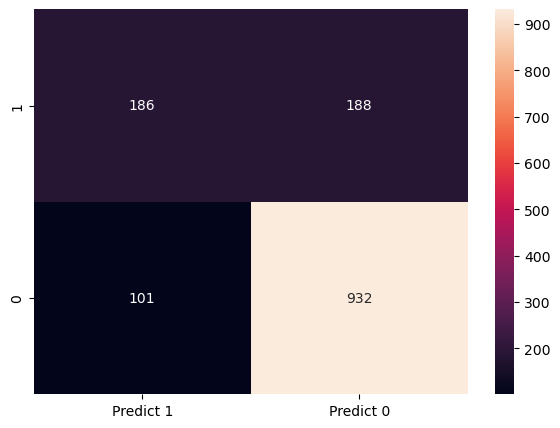

____________________________________________________________
        Classification Report on testing data
____________________________________________________________
              precision    recall  f1-score   support

           1       0.65      0.50      0.56       374
           0       0.83      0.90      0.87      1033

    accuracy                           0.79      1407
   macro avg       0.74      0.70      0.71      1407
weighted avg       0.78      0.79      0.79      1407

____________________________________________________________
      Confusion Matrix on Training data               
____________________________________________________________


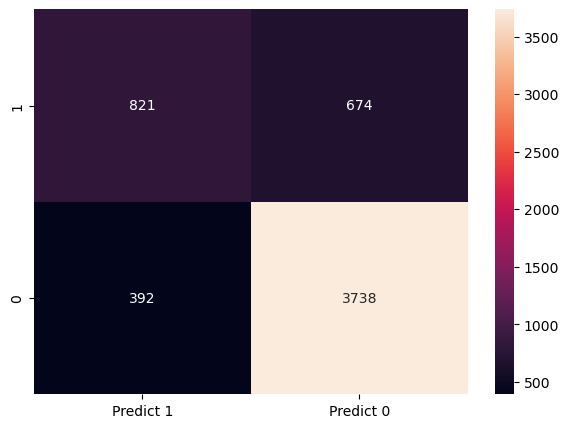

____________________________________________________________
        Classification Report on Training data
____________________________________________________________
              precision    recall  f1-score   support

           1       0.68      0.55      0.61      1495
           0       0.85      0.91      0.88      4130

    accuracy                           0.81      5625
   macro avg       0.76      0.73      0.74      5625
weighted avg       0.80      0.81      0.80      5625



In [284]:
Performance_parameters(AdaBoost,X_test,X_train,y_test,y_train)

In [285]:
Importance=AdaBoost.feature_importances_
Feature_names=AdaBoost.feature_names_in_

print("Feature importance for Decision Tree Tuned model is as given below")
Feature_importance=pd.DataFrame(data=[Feature_names,Importance],index=["Feature","Importance"])
print(Feature_importance.T)

Feature importance for Decision Tree Tuned model is as given below
                                  Feature Importance
0                                  tenure       0.22
1                          MonthlyCharges       0.14
2                            TotalCharges       0.28
3                             gender_Male        0.0
4                         SeniorCitizen_1       0.02
5                             Partner_Yes        0.0
6                          Dependents_Yes        0.0
7                        PhoneService_Yes       0.02
8          MultipleLines_No phone service       0.02
9                       MultipleLines_Yes       0.02
10            InternetService_Fiber optic       0.06
11                     InternetService_No        0.0
12     OnlineSecurity_No internet service        0.0
13                     OnlineSecurity_Yes       0.02
14       OnlineBackup_No internet service        0.0
15                       OnlineBackup_Yes       0.02
16                   DeviceProte

**F. Use grid search and improve the performance of the Adaboost model , check the performance of the model on train and test data , provide the differences observed in performance in Q3.e and Q3.f**

The hypertuning parameters for Adaboost are as below:
 - algorith
 - n_estimators: maximum number of estimators at which boosting is terminated
 - learning_rate: Weight applied to each classifier at each boosting iteration

In [65]:
#Initiatilizing the hyper parameters with the values to do the grid search
algorithm= ["SAMME", "SAMME.R"]
n_estimators=[50,100,150,200]
learning_rate=[0.0001, 0.001, 0.01, 0.1, 1.0]
hyperparameters = dict(algorithm=algorithm,n_estimators=n_estimators,learning_rate=learning_rate)
#Initializing the model as Random Forest
AdaBoost_tune=AdaBoostClassifier()

#Using gridsearch
clf=GridSearchCV(AdaBoost_tune,hyperparameters,cv=5)

#fitting the training data in grid search
best_model=clf.fit(X_train,y_train)

print("The value of best Hyperparameters")
print('Best algorithm:', best_model.best_estimator_.get_params()['algorithm'])
print("Best value for n_estimators: ",best_model.best_estimator_.get_params()["n_estimators"])
print("Best value for the learning_rate: ",best_model.best_estimator_.get_params()["learning_rate"])

The value of best Hyperparameters
Best algorithm: SAMME.R
Best value for n_estimators:  200
Best value for the learning_rate:  0.1


In [286]:
#Creating model using the tuned parameters
AdaBoost_Tuned=AdaBoostClassifier(algorithm="SAMME.R",n_estimators=200,learning_rate=0.1,random_state=1)
AdaBoost_Tuned.fit(X_train,y_train)

AdaBoostClassifier(learning_rate=0.1, n_estimators=200, random_state=1)

Accuracy of the model for the training data is:  0.8083555555555556
Accuracy of the model for the testing data is:  0.7931769722814499
____________________________________________________________
      Confusion Matrix on Testing data               
____________________________________________________________


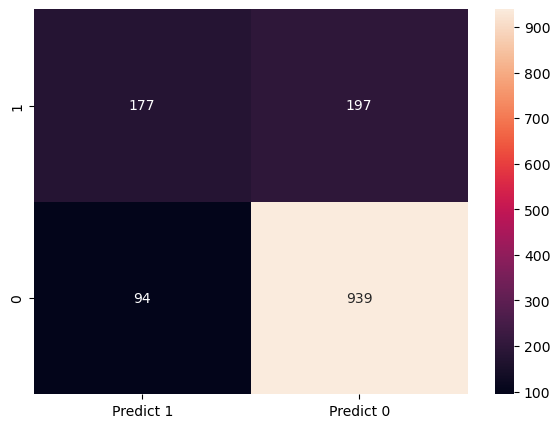

____________________________________________________________
        Classification Report on testing data
____________________________________________________________
              precision    recall  f1-score   support

           1       0.65      0.47      0.55       374
           0       0.83      0.91      0.87      1033

    accuracy                           0.79      1407
   macro avg       0.74      0.69      0.71      1407
weighted avg       0.78      0.79      0.78      1407

____________________________________________________________
      Confusion Matrix on Training data               
____________________________________________________________


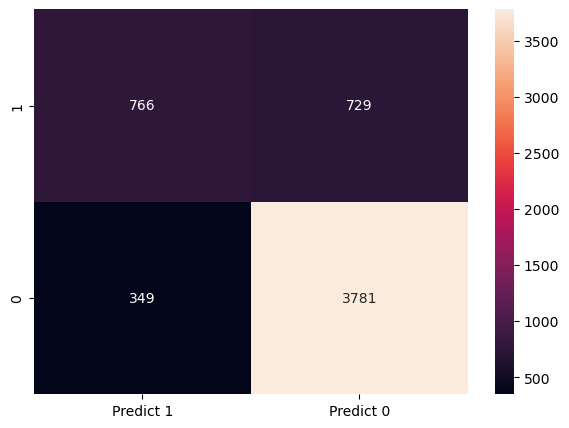

____________________________________________________________
        Classification Report on Training data
____________________________________________________________
              precision    recall  f1-score   support

           1       0.69      0.51      0.59      1495
           0       0.84      0.92      0.88      4130

    accuracy                           0.81      5625
   macro avg       0.76      0.71      0.73      5625
weighted avg       0.80      0.81      0.80      5625



In [287]:
Performance_parameters(AdaBoost_Tuned,X_test,X_train,y_test,y_train)

In [288]:
Importance=AdaBoost_Tuned.feature_importances_
Feature_names=AdaBoost_Tuned.feature_names_in_

print("Feature importance for Decision Tree Tuned model is as given below")
Feature_importance=pd.DataFrame(data=[Feature_names,Importance],index=["Feature","Importance"])
print(Feature_importance.T)

Feature importance for Decision Tree Tuned model is as given below
                                  Feature Importance
0                                  tenure       0.23
1                          MonthlyCharges       0.06
2                            TotalCharges      0.145
3                             gender_Male        0.0
4                         SeniorCitizen_1       0.03
5                             Partner_Yes        0.0
6                          Dependents_Yes       0.01
7                        PhoneService_Yes      0.015
8          MultipleLines_No phone service       0.01
9                       MultipleLines_Yes       0.04
10            InternetService_Fiber optic      0.055
11                     InternetService_No      0.015
12     OnlineSecurity_No internet service      0.015
13                     OnlineSecurity_Yes      0.025
14       OnlineBackup_No internet service       0.02
15                       OnlineBackup_Yes      0.025
16                   DeviceProte

**Adaboost base model**
- Accuracy with the testing and training data are almost the same with 81% for training data and 79% for testing data. Clearly stating that there is no overfitting of the training data in the model <br>
Performance for 1:
- Recall is 50% with the testing data, which means half the actual positives are getting detected by the model
- Precision is 65% which is the same as that of the base model
F1-score is 56%
Performance for 0:
- 90% of the actual negatives are getting correctly identified by the model
- 83% of the actual negatives have been identified  correctly by the model
- There is a clear bias for identifying the nagatives correctly by the model, this is due to the data imbalance

**Adaboost Model with the tuned parameters**
- Accuracy for the training and testing data are the same at 80% clearly stating that there is no overfitting of the training data in the model <br>
Performance for 1:
- Recall for the tuned model has reduced to 47% from 50% with the testing data
- Precision is 65% which means 65% of the predicted positives are correct
- F1-score has slightly reduced due to the reduction in the Recall for the model<br>
Performance for 0:
- 91% of the actual negatives are getting correctly identified by the model
- Precision for the base model and tuned model are the same

**G. Train a model using GradientBoost and check the performance of the model on train and test data**

In [289]:
GradientBoost=GradientBoostingClassifier(random_state=1)
GradientBoost.fit(X_train,y_train)

GradientBoostingClassifier(random_state=1)

Accuracy of the model for the training data is:  0.8277333333333333
Accuracy of the model for the testing data is:  0.7896233120113717
____________________________________________________________
      Confusion Matrix on Testing data               
____________________________________________________________


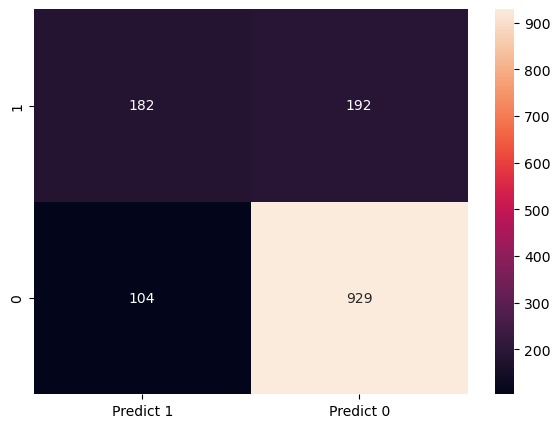

____________________________________________________________
        Classification Report on testing data
____________________________________________________________
              precision    recall  f1-score   support

           1       0.64      0.49      0.55       374
           0       0.83      0.90      0.86      1033

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.71      1407
weighted avg       0.78      0.79      0.78      1407

____________________________________________________________
      Confusion Matrix on Training data               
____________________________________________________________


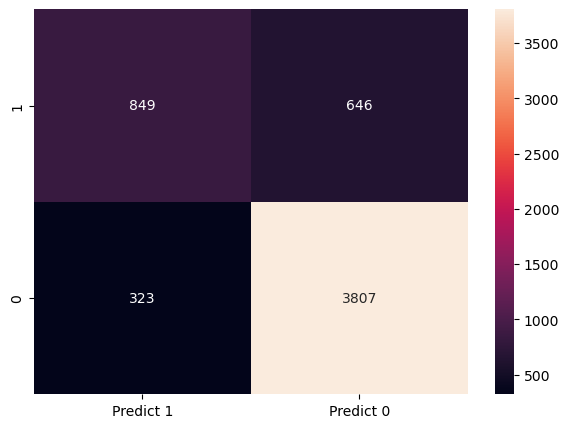

____________________________________________________________
        Classification Report on Training data
____________________________________________________________
              precision    recall  f1-score   support

           1       0.72      0.57      0.64      1495
           0       0.85      0.92      0.89      4130

    accuracy                           0.83      5625
   macro avg       0.79      0.74      0.76      5625
weighted avg       0.82      0.83      0.82      5625



In [290]:
Performance_parameters(GradientBoost,X_test,X_train,y_test,y_train)

In [291]:
Importance=GradientBoost.feature_importances_
Feature_names=GradientBoost.feature_names_in_

print("Feature importance for Decision Tree Tuned model is as given below")
Feature_importance=pd.DataFrame(data=[Feature_names,Importance],index=["Feature","Importance"])
print(Feature_importance.T)

Feature importance for Decision Tree Tuned model is as given below
                                  Feature Importance
0                                  tenure   0.324088
1                          MonthlyCharges   0.071743
2                            TotalCharges   0.064392
3                             gender_Male   0.001755
4                         SeniorCitizen_1   0.005821
5                             Partner_Yes        0.0
6                          Dependents_Yes   0.003229
7                        PhoneService_Yes   0.003847
8          MultipleLines_No phone service   0.003805
9                       MultipleLines_Yes   0.004751
10            InternetService_Fiber optic   0.211728
11                     InternetService_No   0.004023
12     OnlineSecurity_No internet service   0.000896
13                     OnlineSecurity_Yes   0.010274
14       OnlineBackup_No internet service   0.002057
15                       OnlineBackup_Yes   0.003307
16                   DeviceProte

**H. Use grid search and improve the performance of the GradientBoost model , check the performance of the model on train and test data , provide the differences observed in performance in Q3.g and Q3.h**

The hypertuning parameters for Gradient Boosting are as below:
 - loss: loss function
 - n_estimators: maximum number of estimators at which boosting is terminated
 - learning_rate: Weight applied to each classifier at each boosting iteration
 - criterion: The function to measure the quality of a split.{‘friedman_mse’, ‘squared_error’}

In [68]:
loss=["log_loss", "exponential"]
n_estimators=[100,150,200]
learning_rate=[0.0001, 0.001, 0.01, 0.1, 1.0]
criterion=["friedman_mse","squared_error"]
hyperparameters=dict(loss=loss,n_estimators=n_estimators,learning_rate=learning_rate,criterion=criterion)
GBoost_tune=GradientBoostingClassifier()

#using grid search
clf=GridSearchCV(GBoost_tune,hyperparameters,cv=5)

best_model=clf.fit(X_train,y_train)

print("Best hyperparameters for the model are")
print("Best loss function",best_model.best_estimator_.get_params()["loss"])
print("Best n_estimators",best_model.best_estimator_.get_params()["n_estimators"])
print("Best learning_rate",best_model.best_estimator_.get_params()["learning_rate"])
print("Best criterion",best_model.best_estimator_.get_params()["criterion"])

Best hyperparameters for the model are
Best loss function exponential
Best n_estimators 100
Best learning_rate 0.1
Best criterion friedman_mse


In [292]:
GradientBoost_Tuned=GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, criterion="friedman_mse",loss="exponential",random_state=1)
GradientBoost_Tuned.fit(X_train,y_train)

GradientBoostingClassifier(loss='exponential', random_state=1)

Accuracy of the model for the training data is:  0.8236444444444444
Accuracy of the model for the testing data is:  0.7945984363894811
____________________________________________________________
      Confusion Matrix on Testing data               
____________________________________________________________


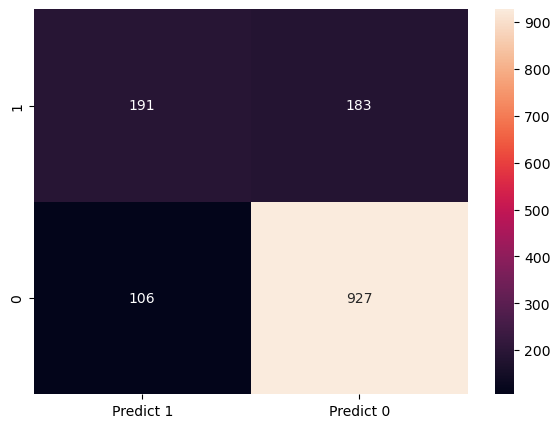

____________________________________________________________
        Classification Report on testing data
____________________________________________________________
              precision    recall  f1-score   support

           1       0.64      0.51      0.57       374
           0       0.84      0.90      0.87      1033

    accuracy                           0.79      1407
   macro avg       0.74      0.70      0.72      1407
weighted avg       0.78      0.79      0.79      1407

____________________________________________________________
      Confusion Matrix on Training data               
____________________________________________________________


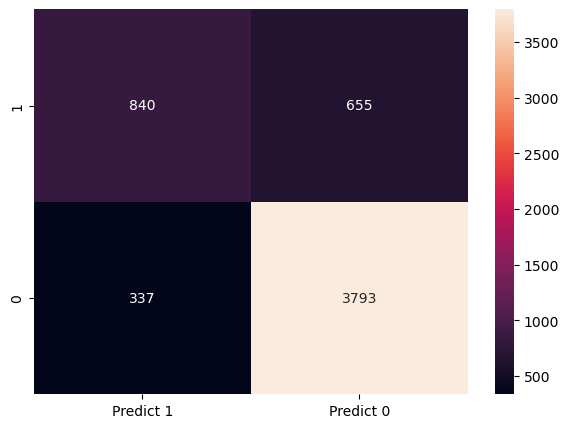

____________________________________________________________
        Classification Report on Training data
____________________________________________________________
              precision    recall  f1-score   support

           1       0.71      0.56      0.63      1495
           0       0.85      0.92      0.88      4130

    accuracy                           0.82      5625
   macro avg       0.78      0.74      0.76      5625
weighted avg       0.82      0.82      0.82      5625



In [293]:
Performance_parameters(GradientBoost_Tuned,X_test,X_train,y_test,y_train)

In [294]:
Importance=GradientBoost_Tuned.feature_importances_
Feature_names=GradientBoost_Tuned.feature_names_in_

print("Feature importance for Decision Tree Tuned model is as given below")
Feature_importance=pd.DataFrame(data=[Feature_names,Importance],index=["Feature","Importance"])
print(Feature_importance.T)

Feature importance for Decision Tree Tuned model is as given below
                                  Feature Importance
0                                  tenure   0.319509
1                          MonthlyCharges   0.060532
2                            TotalCharges   0.078573
3                             gender_Male   0.003097
4                         SeniorCitizen_1   0.006237
5                             Partner_Yes   0.001253
6                          Dependents_Yes   0.002284
7                        PhoneService_Yes   0.002921
8          MultipleLines_No phone service   0.002844
9                       MultipleLines_Yes   0.004537
10            InternetService_Fiber optic   0.204778
11                     InternetService_No   0.005356
12     OnlineSecurity_No internet service   0.012613
13                     OnlineSecurity_Yes   0.009642
14       OnlineBackup_No internet service   0.003338
15                       OnlineBackup_Yes   0.005294
16                   DeviceProte

**Gradient Boosting Base model**
- Accuracy of the model is 82% with the training data and 79% with the testing data. The accuracies are not very different so we can say that there is not much overfitting with the training data <br>
Performance for 1:
- Precision for the model is 64%, so the model can correclty predict 64% of the actual positives
- Recall has not improved much when comparing to the previous models
- F1-score is 55% <br>
Performance for 0:
- Recall is very high with a score of 90%
- Precision is also good with a score of 83%

**Gradient Boosting Tuned Model**
- Accuracy for the model for both the training data and testing data are same as that of the base model<br>
Performance for 1:
- Recall has improved from that of the base model with a value of 51%
- F1-score has also improved from the base model with a score of 57%
- Precision remains that same as that of the base model<br>
Performance with 0:
- Precision, Recall and F1-score remains the same as that of the base model

**I. Provide detailed analysis of the below steps**

(1) Compare the performance of each model in train stage and test stage <br>
(2) Provide your observation on which model performed the best <br>
(3) Provide your reasoning on why the model performed best <br>
(4) Provide your final conclusion on your observation <br>

In [295]:
Models=[DTree,DTree_Tuned,R_Forest,R_Forest_Tuned,AdaBoost,AdaBoost_Tuned,GradientBoost,GradientBoost_Tuned]
Precision_Testing=[]
Precision_Training=[]
Recall_Testing=[]
Recall_Training=[]
F1_score_Testing=[]
F1_score_Training=[]
Accuracy_Testing=[]
Accuracy_Training=[]

for model in Models:
    y_train_pred=model.predict(X_train)
    y_test_pred=model.predict(X_test)
    report_test=metrics.classification_report(y_test, y_test_pred, labels=[1, 0],output_dict=True)
    report_train=metrics.classification_report(y_train, y_train_pred, labels=[1, 0],output_dict=True)
    Precision_Testing.append("{:.2f}".format(report_test["1"]["precision"]))
    Precision_Training.append("{:.2f}".format(report_train["1"]["precision"]))
    Recall_Testing.append("{:.2f}".format(report_test["1"]["recall"]))
    Recall_Training.append("{:.2f}".format(report_train["1"]["recall"]))
    F1_score_Testing.append("{:.2f}".format(report_test["1"]["f1-score"]))
    F1_score_Training.append("{:.2f}".format(report_train["1"]["f1-score"]))
    Accuracy_Testing.append("{:.2f}".format(report_test["accuracy"]))
    Accuracy_Training.append("{:.2f}".format(report_train["accuracy"]))

In [296]:
col_names=["Precision_Testing","Precision_Training","Recall_Testing","Recall_Training","F1_score_Testing","F1_score_Training","Accuracy_Testing","Accuracy_Training"]
data=pd.DataFrame(data=[Precision_Testing,Precision_Training,Recall_Testing,Recall_Training,F1_score_Testing,F1_score_Training,Accuracy_Testing,Accuracy_Training],columns=["DTree","DTree_Tuned","R_Forest","R_Forest_Tuned","AdaBoost","AdaBoost_Tuned","GradientBoost","GradientBoost_Tuned"],
                 index=col_names)

In [297]:
data.T

,Precision_Testing,Precision_Training,Recall_Testing,Recall_Training,F1_score_Testing,F1_score_Training,Accuracy_Testing,Accuracy_Training
DTree,0.51,1.00,0.52,0.99,0.52,0.99,0.74,1.00
DTree_Tuned,0.60,0.67,0.42,0.48,0.50,0.56,0.77,0.80
R_Forest,0.63,0.99,0.47,0.99,0.54,0.99,0.79,1.00
R_Forest_Tuned,0.66,0.77,0.47,0.58,0.55,0.66,0.79,0.84
AdaBoost,0.65,0.68,0.50,0.55,0.56,0.61,0.79,0.81
AdaBoost_Tuned,0.65,0.69,0.47,0.51,0.55,0.59,0.79,0.81
GradientBoost,0.64,0.72,0.49,0.57,0.55,0.64,0.79,0.83
GradientBoost_Tuned,0.64,0.71,0.51,0.56,0.57,0.63,0.79,0.82


**(1) Compare the performance of each model in train stage and test stage**

**Decision Tree Base Model (DTree)**
- Decision tree base model is clearly overfitting in the training stage with an accuracy of 100% in the training stage and an accuracy of only 74% in testing stage
- Recall with the testing data is only 52% while that with the training data is 99%
- Infact, the performance parameters like precision, recall and F1-score are reduced to half with the testing data when comparing the same scores for the training data
- The vast difference in the scores in the testing stage and training stage is clearly due to the model overfitting the training data

**Decision Tree with Tuned hyper parameters (DTree_Tuned)**
- Decision tree with the tuned hyper parameters (DTree_Tuned) is having an accuracy that almost matches that of the testing stage so this shows that the tuned model is not overfitting the training data.
- Recall,precision and F1-score for the tuned model in the testing stage is lower than that of the training stage but overall the performance metrics is not satisfactory

**Random Forest Base Model (R_Forest)**
- The accuracy for the training data is 100% but that for the testing data is 79% this clearly shows an overfitting of the training data in the model
- F1-score and Recall for the training data is very high while the same for the testing data is only 50% of the training data
- precision for the testing data is 63%

**Random Forest Tuned Model (R_Forest_Tuned)**
- Accuracy with the training data and testing data is almost the same with the training data having a slightly higher accuracy with 84% while testing data having an accuracy of 79%
- There is a ~10% reduction when comparing the precision, recall and F1-score in training and testing data with training data having the upper hand
- Recall value is only 47% with the testing data

**AdaBoosting Base Model (AdaBoost)**
- Accuracy with training and testing data are almost the same with training data having an accuracy of 81% and testing data with 79%. This clearly shows that there is no overfitting of the traning data in the model
- Recall and F1-score with the training data is higher than the testing data by 5%
- Precision with the training data is almost the same as with the testing data

**AdaBoosting Tuned Model (AdaBoost_Tuned)**
- The adaboosting base model and the tuned model are having the same accuracy both with the training data as well as the testing data
- The recall for both training data and testing data is lesser for the tuned model than the base model
- F1-score is less which is because of the reduction in the recall in the testing data

**Gradient Boosting Base Model (GradientBoost)**
- Accuracy is almost the same with the training data and testing data
- There is almost an 8% difference in the performance scores precision, recall and F1-score for the training data and testing data
- Recall with the training data is only 49%

**Gradient Boosting Tuned Model (GradientBoost_Tuned)**
- Accuracy for the training data is 82% and that for the testing data is 79% which is very close
- 64% is the precision with the testing data while the same for the training data is 71%
- Recall is better with a value of 51% for testing data and 56% for training data
- F1-score is 63% for training data and 57% for testing data

**(2) Provide your observation on which model performed the best**

Among the models that were formed, Gradient Boosting with the tuned parameters (GradientBoost_Tuned) model performed the best

**(3) Provide your reasoning on why the model performed best**

Gradient Boosting model with tuned parameters is selected as the best model because of the below reasons:
- Accuracy with the training data and testing data are almost the same which shows that the noise in the training data is not included in the model.
- There is no training data overfitting in the model
- Objective of the model is to correctly predict all the customers who are likely to churn the service so recall has to be given a higher weightage. Among the models created highest value for recall is for D_Tree but there is a high overfitting of the training data in the D_Tree model.
- GradientBoost_Tuned is having the second highest recall value with a balance in the accuracy of the training data and testing data
- Precision and F1-score are also the best for Gradient Boosting model with the tuned parameters

**(4) Provide your final conclusion on your observation**

- When considering the dataset for creating the model, it is always good to have a balanced dataset so that there is no information loss for the minority class
- The objective of the model is to correctly identify the positives or the customers who are having a higher probability to churn the service so the performance metrics of importance is recall, the better the recall for the testing data, the better the model.
- Since the dataset provided has very less % of datapoints representing the churned class, the model cannot be trained to the best so the performance meausures for the Class 1 is less when compared to that of Class 0
- Among the models that were built, the best recall is identified for the Gradient Boosting with the tuned parameters, though the recall is not very high, it is the best among the built models